# Netflix Dataset EDA

This notebook loads `netflix_titles.csv`, performs basic cleaning, prints summary statistics, and creates key visualizations using Matplotlib and Seaborn.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv("netflix_titles.csv")

# -----------------------------
# Data cleaning
# -----------------------------
text_cols = [
    "director", "cast", "country", "date_added", "rating", "duration", "listed_in", "description"
]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

if "title" in df.columns:
    df["title"] = df["title"].fillna("Untitled")
if "release_year" in df.columns:
    df["release_year"] = df["release_year"].fillna(df["release_year"].median())

if "date_added" in df.columns:
    df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [7]:
# Basic info and summary
print("Dataset Shape:", df.shape)
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())
print("\nBasic Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe(include="all"))

Dataset Shape: (8807, 12)

Missing Values After Cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-nul

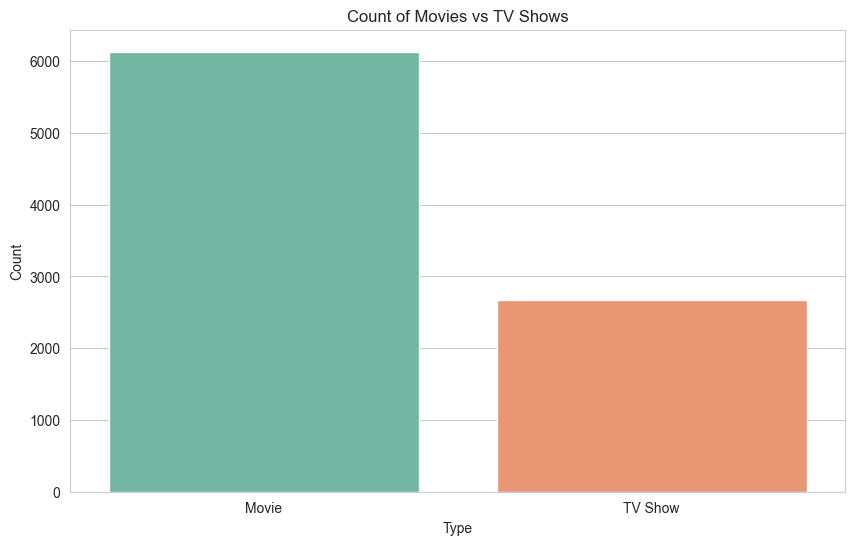

In [8]:
# 1) Count of Movies vs TV Shows
plt.figure()
sns.countplot(data=df, x="type", hue="type", palette="Set2", legend=False)
plt.title("Count of Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

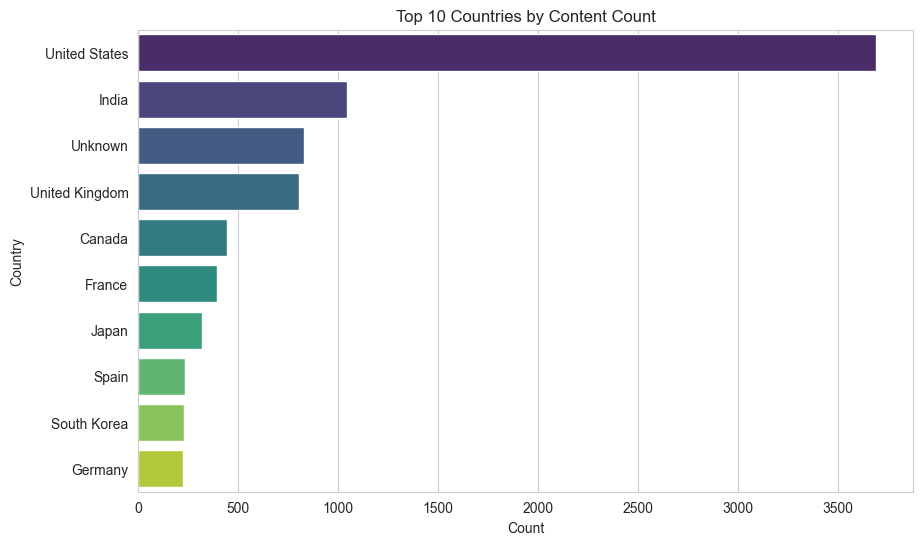

In [9]:
# 2) Top 10 countries
country_series = (
    df["country"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
)

top_10_countries = country_series[country_series != ""].value_counts().head(10)
plot_countries = top_10_countries.reset_index()
plot_countries.columns = ["country", "count"]

plt.figure()
sns.barplot(data=plot_countries, x="count", y="country", hue="country", palette="viridis", legend=False)
plt.title("Top 10 Countries by Content Count")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

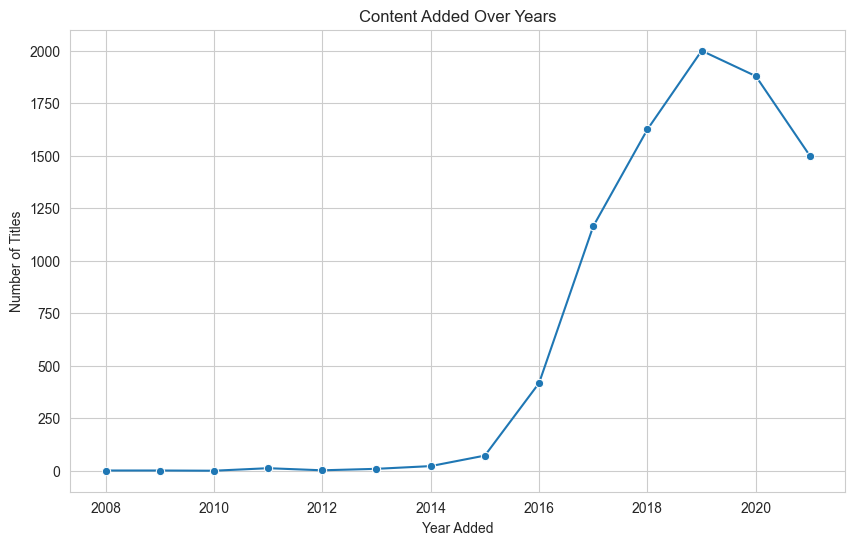

In [10]:
# 3) Content added over years
added_by_year = df["date_added"].dt.year.value_counts().sort_index()

plt.figure()
sns.lineplot(x=added_by_year.index, y=added_by_year.values, marker="o")
plt.title("Content Added Over Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

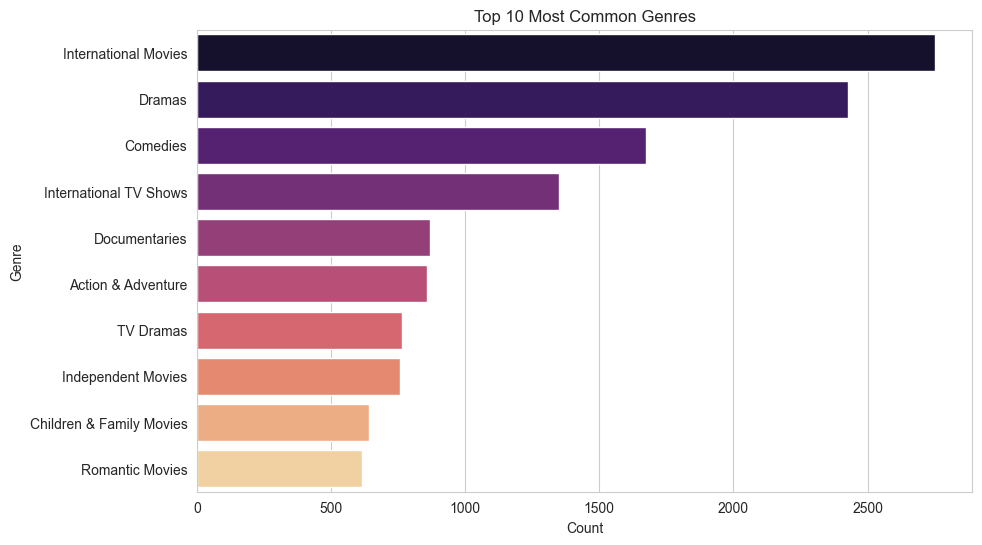

In [11]:
# 4) Most common genres
genre_series = (
    df["listed_in"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
)

top_genres = genre_series[genre_series != ""].value_counts().head(10)
plot_genres = top_genres.reset_index()
plot_genres.columns = ["genre", "count"]

plt.figure()
sns.barplot(data=plot_genres, x="count", y="genre", hue="genre", palette="magma", legend=False)
plt.title("Top 10 Most Common Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

Key Insights
Netflix has a significantly higher number of Movies compared to TV Shows, indicating a stronger focus on film-based content.
The majority of content is produced in the United States, showing regional dominance in content creation.
There is a noticeable increase in content addition after 2015, reflecting Netflix’s global expansion strategy.
Certain genres like Drama and International Movies dominate the platform, suggesting user preference trends.

Conclusion

This analysis highlights Netflix’s content strategy focused on movies, dominant production regions, and rapid growth in recent years. The insights can help understand user demand patterns and guide content acquisition strategies.